# Вариант 4-4

**Калягин Дмитрий, Аверьянова Мария**

**ИАД-25**

--------------------------------------------------------------

## Задача оптимизации
$$f(x) = \frac{p}{2} \Vert Ax - b \Vert ^2 + \sum_{i=1}^m \log \bigg( 2 \cosh \big(u_i^\top (x - a)\big)\bigg),$$


$$
a \in \R^n, b \in \R^m, A \in \R^{m \times n}, u_i \in \R^n, p \ge 0, m=\frac{n}{5} \\
x \in \R^n - переменная~оптимизации, \Vert \cdot \Vert - евклидова~норма
$$

**Введенные ограничения:**
$$
q^\top x \le \eta
$$

## Проверка множества допустимых точек

Множество $C \subset \R^n$ называется выпуклым, если $\forall  x_1, x_2 \in C$ и $\forall \lambda \in [0, 1]$:

$$
x_{\lambda} = \lambda x_1 + (1 - \lambda)x_2 \in C
$$

То есть, если взять любые две точки и рассматриваемого множеста, то весь отрезок между ними так же лежит в этом множестве.

---

Учитывая новое ограничение, нужно проверить:
$$
q^\top x_{\lambda} \le \eta
$$

Пусть
$$
q^\top x_1 \le \eta \\
q^\top x_2 \le \eta
$$

Возьмем
$$
x_{\lambda} = \lambda x_1 + (1 - \lambda) x_2
$$

Тогда
$$
q^\top x_{\lambda} = q^\top \bigg( \lambda x_1 + (1 - \lambda) x_2 \bigg) \\
= \lambda q^\top x_1 + (1 - \lambda) q^\top x_2
$$

Так как 
$$
q^\top x_1 \le \eta, \quad q^\top x_2 \le \eta
$$

Можем оценить полученное выражение
$$
\lambda q^\top x_1 + (1 - \lambda) q^\top x_2 \le \lambda \eta + (1 - \lambda) \eta \\
= \eta \quad \Longrightarrow \quad q^\top x_{\lambda} \le \eta
$$
$\square$

Следовательно множество допустимых точек:
$$
C = \{ x \in \R^n \, | \, q^\top x \le \eta \}
$$
является выпуклым множеством.


In [ ]:
import time
import numpy as np
from tqdm import tqdm
from multiprocessing import Pool

# from utils import plot_results

np.random.seed(42)

In [60]:
import math
import numpy as np
import matplotlib.pyplot as plt


def aggregate_histories(problems):
    histories = []

    for problem in problems:
        h = problem["best"]["history"]
        if h:
            histories.append(h)

    if not histories:
        return []

    min_len = min(len(h) for h in histories)
    histories = [h[:min_len] for h in histories]

    return np.mean(histories, axis=0)


def create_subplots(n_plots):
    cols = 3
    rows = math.ceil(n_plots / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()

    return fig, axes


def plot_convergence_multi(results_list, titles):
    fig, axes = create_subplots(len(results_list))

    for i, (results, title) in enumerate(zip(results_list, titles)):
        ax = axes[i]

        for n in sorted(results.keys()):
            mean_history = aggregate_histories(results[n])

            if len(mean_history) > 0:
                ax.plot(mean_history, label=f"n={n}")

        ax.set_title(title)
        ax.set_xlabel("Iteration")
        ax.set_ylabel("f(x)")
        ax.grid()
        ax.legend()

    plt.tight_layout()
    plt.show()


def plot_scaling_multi(results_list, titles):
    fig, axes = create_subplots(len(results_list))

    for i, (results, title) in enumerate(zip(results_list, titles)):
        ax = axes[i]

        ns = sorted(results.keys())
        times = []
        iters = []

        for n in ns:
            problems = results[n]
            
            times_n = [p["best"]["time"] for p in problems]
            iters_n = [p["best"]["iterations"] for p in problems if p["best"]["iterations"]]

            times.append(np.mean(times_n) * 1000)  # миллисекунды
            iters.append(np.mean(iters_n))

        ax.plot(ns, times, marker='o', label="time")
        ax.plot(ns, iters, marker='x', label="iters")

        ax.set_title(title)
        ax.set_xlabel("n")
        ax.set_yscale("log")
        ax.legend()
        ax.grid()

    plt.tight_layout()
    plt.show()


def plot_boxplot(results_list, titles):
    fig, axes = create_subplots(len(results_list))

    for i, (results, title) in enumerate(zip(results_list, titles)):
        ax = axes[i]

        data = []

        for n in sorted(results.keys()):
            vals = []

            for problem in results[n]:
                for run in problem["all_runs"]:
                    vals.append(run["f_value"])

            data.append(vals)

        ax.boxplot(data)
        ax.set_title(title)
        ax.set_xlabel("n index")
        ax.set_ylabel("f(x)")
        ax.grid()

    plt.tight_layout()
    plt.show()


def plot_results(results_list, titles, plot_type="convergence"):
    plot_map = {
        "convergence": plot_convergence_multi,
        "scaling": plot_scaling_multi,
        "boxplot": plot_boxplot,
    }

    if plot_type not in plot_map:
        raise ValueError(f"Unknown plot type: {plot_type}")

    plot_map[plot_type](results_list, titles)

In [30]:
def f_value(x, A, b, a, U, p):
    term1 = (p/2) * np.linalg.norm(A @ x - b)**2
    z = U @ (x - a)
    term2 = np.sum(np.log(2*np.cosh(z)))
    return term1 + term2

In [4]:
def estimate_L(A, U, p):
    M = p * A.T @ A + U.T @ U
    return np.linalg.eigvalsh(M).max()

In [5]:
def generate_problem(n, rng):
    if not rng:
        rng = np.random

    m = max(1, n // 5)
    A = rng.randn(m, n)
    b = rng.randn(m)
    a = rng.randn(n)
    U = rng.randn(m, n)
    p = rng.rand() + 0.1
    q = rng.randn(n)
    eta = abs(rng.randn()) + 0.5

    return A, b, a, U, p, q, eta

In [6]:
def generate_start_points(n, num_points=100):
    return [np.random.randn(n) for _ in range(num_points)]

## Введение ограничения

Учитывая введенное ограничение, при выполнении шага градиента необходимо произвести проекцию обновленного значения вектора на множество $q^\top x \le \eta$

**Что такое проекция на множество**

Проекция точки $x$ на множество $C$ - это точка:

$$
\Pi_C(x) = \arg \underset{y \in C}{\min} \Vert y-x \Vert^2
$$

то есть ближайшая к $x$ точка из допустимого множества.

$$
C = \{ y \mid q^\top y \le \eta \}
$$

Если
$$
q^\top x \gt \eta
$$
то точка вне полупространства.

Нужно найти ближайшую точку - точку на границе, то есть:
$$
q^\top x = \eta
$$

Нужно решить задачу с линейным ограничением:
$$
\begin{cases}
    \underset{y}{\min} \Vert y-x \Vert^2 &\\
    q^\top x = \eta
\end{cases}
$$

Функция Лагранжа (инимизируем по $y$):
$$
L(y,\lambda) = \Vert y-x \Vert ^2 + \lambda (q^\top y - \eta)
$$

Ее градиент:
$$
\nabla_y L = 2(y-x) + \lambda q
$$

Минимум:
$$
2(y-x) + \lambda q  = 0  \\
y = x - \frac{\lambda}{2}q
$$

Подставляем в ограничение:
$$
q^\top \Big( x - \frac{\lambda}{2}q \Big) = \eta
\\
q^\top x = \frac{\lambda}{2} q^\top q = \eta
\\
\lambda = 2 \frac{q^\top x - \eta}{q^\top q}
$$

Подставляем обратно в $y$:
$$
y = x - \frac{q^\top x - \eta}{q^\top q}q
$$

Получаем формулу проекции:
$$
\Pi_{\{q^\top x = \eta\}}(x) = x - \frac{q^\top x - \eta}{\Vert q \Vert ^2}q
$$

Тогда получаем:

$$
\boxed{
    \Pi(x) =
    \begin{cases}
        x, & если \ q^\top \le \eta &\\
        x - \frac{q^\top x - \eta}{\Vert q \Vert ^2} q, & иначе
    \end{cases}
}
$$
где
$$
C = \{ x \mid q^\top y \le \eta \}
$$

In [7]:
def project(x, q, eta):
    if q @ x <= eta:
        return x

    return x - ((q @ x - eta) / (q @ q)) * q

In [8]:
class GradientStrategy:

    def __init__(self, opt):
        self.opt = opt

    def compute(self, x, k):
        raise NotImplementedError

    def step_size(self, k):
        return 1.0 / self.opt.L

## Полный градиент

In [9]:
def gradient(x, A, b, a, U, p):
    g1 = p * A.T @ (A @ x - b)
    z = U @ (x - a)
    g2 = U.T @ np.tanh(z)

    return g1 + g2

In [10]:
class CompleteGradient(GradientStrategy):

    def compute(self, x, k):
        return gradient(
            x,
            self.opt.A,
            self.opt.b,
            self.opt.a,
            self.opt.U,
            self.opt.p,
        )

## Стохастический градиент

Нужно представить
$$
f(x) = \sum_{i=1}^M \phi_i(x)
$$

и вместо полного градиента использовать
$$
g(x^k, \xi^k) = M \nabla \phi_{\xi^k}(x^k)
$$

где
$$
\xi^k \sim \text{Unif}\{1,\dots,M\}
$$

---

Исследуемая функция:
$$
f(x) = \frac{p}{2} \Vert Ax - b \Vert ^2 + \sum_{i=1}^m \log \bigg( 2 \cosh \big(u_i^\top (x - a)\big)\bigg)
$$

Раскроем квадрат:
$$
\Vert Ax-b \Vert ^2 = \sum_{i=1}^m (A_i x - b_i)^2
$$
где $A_i$ - строка $A$.

Получаем:
$$
f(x) = \sum_{i=1}^m \frac{p}{2} (A_i x - b_i)^2 + \sum_{i=1}^m \log \bigg( 2 \cosh \big(u_i^\top (x - a)\big)\bigg)
$$

Видим две суммы по $m$ элементов, тогда в нашем случае $M=m$, значит $\phi_i$:
$$
\phi_i(x) = \frac{p}{2} (A_i x - b_i)^2 + \log \bigg( 2 \cosh \big(u_i^\top (x - a)\big)\bigg)
$$
$$
f(x) = \sum_{i=1}^m \phi_i(x)
$$

---

Проверим градиент:
$$
\nabla \phi_i(x) = p (A_i x - b_i) A_i^\top + \tanh(u_i^\top(x-a)) u_i
$$
Их сумма:
$$
\sum_i \nabla \phi_i = p A^\top (Ax-b) + \sum_{i=1}^{m} \tanh(u_i^\top(x-a)) u_i
$$
то есть градиент полной функции.

Проецируя на алгоритм обновления $x$:
$$
x_{k+1} ​= x_k ​− hg_k​, \quad g_k ​= g(x_k​,\xi_k​) \\
\xi_k \sim \text{Unif}\{1,\dots,M\}
$$


In [11]:
def stochastic_gradient(x, A, b, a, U, p):

    m = A.shape[0]
    i = np.random.randint(m)

    Ai = A[i]
    bi = b[i]
    ui = U[i]

    g1 = p * (Ai @ x - bi) * Ai
    g2 = np.tanh(ui @ (x - a)) * ui

    g = g1 + g2

    return m * g

In [12]:
class StochasticGradient(GradientStrategy):
    def __init__(self, opt):
        super().__init__(opt)
        self.base_lr = 0.3 / opt.L
        self.prev_lr = self.base_lr
        self.decay_started = False
        self.k_switch = None
        self.lr_switch = None
        self.history = []
        self.window = opt.kwargs.get("window", 20)
        self.plateau_tol = opt.kwargs.get("plateau_tol", 1e-2)

    def compute(self, x, k):
        g = stochastic_gradient(
            x,
            self.opt.A,
            self.opt.b,
            self.opt.a,
            self.opt.U,
            self.opt.p,
        )

        # gradient clipping
        g_norm = np.linalg.norm(g)
        if g_norm > 10:
            g = g * (10 / g_norm)

        # сохраняем историю f(x) для адаптивного lr
        fx = f_value(x, self.opt.A, self.opt.b, self.opt.a, self.opt.U, self.opt.p)
        self.history.append(fx)

        # проверка plateau
        if not self.decay_started and len(self.history) > self.window:
            diffs = [
                abs(self.history[-i] - self.history[-i - 1])
                for i in range(1, self.window)
            ]
            avg_diff = np.mean(diffs)
            if avg_diff < self.plateau_tol:
                self.decay_started = True
                self.k_switch = k
                self.lr_switch = self.prev_lr

        return g

    def step_size(self, k):
        if not self.decay_started:
            lr = self.base_lr
        else:
            lr = self.lr_switch / np.sqrt(k - self.k_switch + 1)
        lr = min(lr, self.prev_lr)
        self.prev_lr = lr
        return lr

## Стохастический градиент + минибатчинг

В отличие от обычного стохастического градиента, вместо одного индекса берём несколько ($b$ - размер батча):
$$
S_k = \{ \xi^k_1, \dots, \xi^k_b \}
$$
где
$$
\xi^k_j \sim \text{Unif}\{1,\dots,M\}
$$

Новый градиент:
$$
g(x^k, \xi^k) \rightarrow \frac{1}{b} \sum_{j \in S^k} g(x^k, \xi_j^k)
$$
то есть мы берём $b$ стохастических градиентов и усредняем.

Подставим $g$ из прошлого пункта:
$$
g(x,\xi_j) = M \nabla \phi_{\xi_j}(x)
$$
$$
g_{batch} = \frac{1}{b} \sum^b_{j=1} M \nabla \phi_{\xi_j}(x)
$$

In [13]:
def stochastic_gradient_batch(
    x,
    A, b, a, U, p,
    batch_size,
):
    g = np.zeros_like(x)
    for _ in range(batch_size):
        g += stochastic_gradient(
            x, A, b, a, U, p
        )
    g /= batch_size

    return g

In [14]:
class StochasticMiniBatchGradient(GradientStrategy):

    def __init__(self, opt):
        super().__init__(opt)
        self.batch_size = opt.kwargs.get("batch_size", 4)
        self.base_lr = 0.3 / opt.L
        self.prev_lr = self.base_lr
        self.decay_started = False
        self.k_switch = None
        self.lr_switch = None
        self.history = []
        self.window = opt.kwargs.get("window", 20)
        self.plateau_tol = opt.kwargs.get("plateau_tol", 1e-2)

    def compute(self, x, k):
        g =  stochastic_gradient_batch(
            x,
            self.opt.A,
            self.opt.b,
            self.opt.a,
            self.opt.U,
            self.opt.p,
            self.batch_size,
        )

        # gradient clipping
        g_norm = np.linalg.norm(g)
        if g_norm > 10:
            g = g * (10 / g_norm)

        # сохраняем историю f(x) для адаптивного lr
        fx = f_value(x, self.opt.A, self.opt.b, self.opt.a, self.opt.U, self.opt.p)
        self.history.append(fx)

        # проверка plateau
        if not self.decay_started and len(self.history) > self.window:
            diffs = [
                abs(self.history[-i] - self.history[-i - 1])
                for i in range(1, self.window)
            ]
            avg_diff = np.mean(diffs)
            if avg_diff < self.plateau_tol:
                self.decay_started = True
                self.k_switch = k
                self.lr_switch = self.prev_lr

        return g

    def step_size(self, k):
        if not self.decay_started:
            lr = self.base_lr
        else:
            lr = self.lr_switch / np.sqrt(k - self.k_switch + 1)
        lr = min(lr, self.prev_lr)
        self.prev_lr = lr
        return lr

## Стохастический градиент по правой части функции

Предложим:
$$
g(x, \xi) = p A^\top (Ax-b) + m \tanh(u_\xi^\top (x-a)) u_\xi
$$
где
$$
\xi \sim Unif \{1, \dots, m \}
$$

**Несмещенность**

Нужно показать:
$$
E(g(x,\xi)) = \nabla f(x)
$$

Левая часть не случайная, поэтому:
$$
E(pA^\top(Ax-b)) = pA^\top(Ax-b)
$$

Правая часть:
$$
E(m \tanh(u_\xi^\top(x-a)) u_\xi) = \frac{1}{m} \sum_{i=1}^m m \tanh(u_i^\top(x-a)) u_i
$$
$$
= \sum_{i=1}^m \tanh(u_i^\top(x-a)) u_i
$$

Получаем:
$$
E(g) = pA^\top(Ax-b) + \sum_{i=1}^m \tanh(u_i^\top(x-a)) u_i = \nabla f(x)
$$

$\square$ несмещённость доказана

---

**Ограниченность дисперсии**

Нужно показать что:
$$
E \Vert g(x,\xi) \Vert ^2 \le C
$$

Так как
$$
\vert \tanh(t) \vert \le 1
$$
то 
$$
\Vert \tanh(u_i^\top(x-a)) u_i \Vert \le \Vert u_i \Vert
$$

Значит
$$
\Vert g(x,\xi) \Vert \le \Vert pA^\top(Ax-b) \Vert + m \Vert u_\xi \Vert
$$
Так как матрицы $A$, $U$ фиксированы, существует константа $C$, что
$$
E \Vert g(x,\xi) \Vert ^2 \le C
$$
Следовательно, дисперсия стохастического градиента ограничена.

In [15]:
def stochastic_gradient_new(
    x,
    A, b, a, U, p,
):
    m = A.shape[0]
    i = np.random.randint(m)
    # full quadratic part
    g1 = p * A.T @ (A @ x - b)
    # random cosh part
    ui = U[i]
    g2 = np.tanh(ui @ (x - a)) * ui

    return g1 + m * g2

In [16]:
class StochasticCustomGradient(GradientStrategy):
    def __init__(self, opt):
        super().__init__(opt)
        self.base_lr = 0.3 / opt.L
        self.prev_lr = self.base_lr
        self.decay_started = False
        self.k_switch = None
        self.lr_switch = None
        self.history = []
        self.window = opt.kwargs.get("window", 20)
        self.plateau_tol = opt.kwargs.get("plateau_tol", 1e-2)

    def compute(self, x, k):
        g = stochastic_gradient_new(
            x,
            self.opt.A,
            self.opt.b,
            self.opt.a,
            self.opt.U,
            self.opt.p,
        )

        # gradient clipping
        g_norm = np.linalg.norm(g)
        if g_norm > 10:
            g = g * (10 / g_norm)

        # сохраняем историю f(x) для адаптивного lr
        fx = f_value(x, self.opt.A, self.opt.b, self.opt.a, self.opt.U, self.opt.p)
        self.history.append(fx)

        # проверка plateau
        if not self.decay_started and len(self.history) > self.window:
            diffs = [
                abs(self.history[-i] - self.history[-i - 1])
                for i in range(1, self.window)
            ]
            avg_diff = np.mean(diffs)
            if avg_diff < self.plateau_tol:
                self.decay_started = True
                self.k_switch = k
                self.lr_switch = self.prev_lr

        return g
    
    def step_size(self, k):
        if not self.decay_started:
            lr = self.base_lr
        else:
            lr = self.lr_switch / np.sqrt(k - self.k_switch + 1)
        lr = min(lr, self.prev_lr)
        self.prev_lr = lr
        return lr

In [17]:
def stochastic_gradient_new_batch(
    x,
    A, b, a, U, p,
    batch_size,
):
    g = np.zeros_like(x)
    for _ in range(batch_size):
        g += stochastic_gradient_new(
            x, A, b, a, U, p
        )
    g /= batch_size

    return g

In [18]:
class StochasticCustomMiniBatchGradient(GradientStrategy):

    def __init__(self, opt):
        super().__init__(opt)
        self.batch_size = opt.kwargs.get("batch_size", 4)
        self.base_lr = 0.3 / opt.L
        self.prev_lr = self.base_lr
        self.decay_started = False
        self.k_switch = None
        self.lr_switch = None
        self.history = []
        self.window = opt.kwargs.get("window", 20)
        self.plateau_tol = opt.kwargs.get("plateau_tol", 1e-2)

    def compute(self, x, k):
        g = stochastic_gradient_new_batch(
            x,
            self.opt.A,
            self.opt.b,
            self.opt.a,
            self.opt.U,
            self.opt.p,
            self.batch_size,
        )

        # gradient clipping
        g_norm = np.linalg.norm(g)
        if g_norm > 10:
            g = g * (10 / g_norm)

        # сохраняем историю f(x) для адаптивного lr
        fx = f_value(x, self.opt.A, self.opt.b, self.opt.a, self.opt.U, self.opt.p)
        self.history.append(fx)

        # проверка plateau
        if not self.decay_started and len(self.history) > self.window:
            diffs = [
                abs(self.history[-i] - self.history[-i - 1])
                for i in range(1, self.window)
            ]
            avg_diff = np.mean(diffs)
            if avg_diff < self.plateau_tol:
                self.decay_started = True
                self.k_switch = k
                self.lr_switch = self.prev_lr

        return g
    
    def step_size(self, k):
        if not self.decay_started:
            lr = self.base_lr
        else:
            lr = self.lr_switch / np.sqrt(k - self.k_switch + 1)
        lr = min(lr, self.prev_lr)
        self.prev_lr = lr
        return lr

## Реализация методов градиентного спуска

In [76]:
class BaseOptimizer:
    def __init__(
        self,
        A, b, a, U, p, q, eta,
        grad_type="complete",
        eps=1e-2,
        max_iter=10000,
        **kwargs,
    ):
        self.A = A
        self.b = b
        self.a = a
        self.U = U
        self.p = p
        self.q = q
        self.eta = eta

        self.grad_type = grad_type
        self.eps = eps
        self.max_iter = max_iter

        self.kwargs = kwargs
        self.n = self.A.shape[1]
        self._handle_batch()

        self.L = estimate_L(A, U, p)

        self.grad_strategy = self._make_grad_strategy(grad_type)
    
    def _handle_batch(self):
        bs = self.kwargs.get("batch_size")
        if isinstance(bs, int):
            pass
        elif isinstance(bs, str):
            if bs == "n/10":
                self.kwargs["batch_size"] = self.n // 10
            elif bs == "n/5":
                self.kwargs["batch_size"] = self.n // 5
            elif bs == "n/2":
                self.kwargs["batch_size"] = self.n // 2
            elif bs == "n":
                self.kwargs["batch_size"] = self.n
            else:
                raise ValueError(f"Incorrect batch_size key: {bs}")
        else:
            raise ValueError(f"Incorrect batch type: {type(bs)}")

    def _make_grad_strategy(self, grad_type):

        if grad_type == "complete":
            return CompleteGradient(self)

        elif grad_type == "stochastic":
            return StochasticGradient(self)

        elif grad_type == "stochastic_mini_batch":
            return StochasticMiniBatchGradient(self)

        elif grad_type == "stochastic_custom":
            return StochasticCustomGradient(self)

        elif grad_type == "stochastic_custom_mini_batch":
            return StochasticCustomMiniBatchGradient(self)

        else:
            raise ValueError(f"Unknown grad_type {grad_type}")

    def grad(self, x, k):
        return self.grad_strategy.compute(x, k)

    def step_size(self, k):
        return self.grad_strategy.step_size(k)

    # common helpers
    def project(self, x):
        return project(x, self.q, self.eta)

    def f(self, x):
        return f_value(x, self.A, self.b, self.a, self.U, self.p)

    def solve(self, x0):
        raise NotImplementedError

### Метод линейного каплинга с моментумом

$ y = x - lr \cdot \nabla f(x) $ - градиентный шаг

$ z_{k+1} = z_k + \beta (z_k - z_{k-1}) - \gamma \cdot \nabla f(x) $ - моментум с поправкой на градиент \
Здесь $(z_k - z_{k-1})$ - это скорость сходимости, $\beta$ отвечает за сохранение направления движения, а $(- \gamma \cdot \nabla f(x))$ поправка на градиент

$ x_{k+1} = \tau \cdot z_{k+1} + (1 - \tau) \cdot y $ - каплинг (смешивание) градиентного спуска и моментума с параметром $\tau$

In [77]:
class LinearCoupling(BaseOptimizer):

    def solve(self, x0):
        x = x0.copy()
        z = x0.copy()
        z_prev = x0.copy()

        history = []

        beta = self.kwargs.get("beta", 0.7)
        tau = self.kwargs.get("tau", 0.3)

        for k in range(self.max_iter):
            g = self.grad(x, k)
            lr = self.step_size(k)

            # clipping
            g_norm = np.linalg.norm(g)
            if g_norm > 10:
                g = g * (10 / g_norm)

            y = x - lr * g
            z_new = z + beta * (z - z_prev) - lr * g
            x_new = tau * z_new + (1 - tau) * y
            x_new = self.project(x_new)

            if np.linalg.norm(x_new - x) < self.eps:
                break

            z_prev = z
            z = z_new
            x = x_new

            history.append(self.f(x))

        return x, history

### Метод момента Нестерова

**Константы:**

$h = \frac{1}{L}$ - градиентный шаг оптимизации

$\tau = \frac{\sqrt{L} - \sqrt{\mu}}{\sqrt{L} + \sqrt{\mu}}$ - в нашем случае $\mu = 0$ всегда, поэтому $\tau = 1$ 

**Алгоритм:**

Двигаемся дальше в направлении предыдущего шага:
$$
y_k​ = x_k ​+ \tau ( x_k​ − x_{k−1}​)
$$

Считаем градиент в новой точке:
$$
g_k​ = \nabla f(y_k​)
$$

Двигаемся дальше в направлении антиградиента в новой точке:
$$
x_{k+1} = y_k ​− h \nabla f(y_k​)
$$
точнее в нашем случае с ограничением:
$$
x_{k+1} = \Pi​(y_k ​− hg_k​)
$$

In [78]:
class Nesterov(BaseOptimizer):

    def solve(self, x0):
        x = x0.copy()
        x_prev = x0.copy()

        tau = self.kwargs.get("tau", 1.0)

        history = []
        for k in range(self.max_iter):
            y = x + tau * (x - x_prev)
            g = self.grad(y, k)

            lr = self.step_size(k)

            x_new = y - lr * g
            x_new = self.project(x_new)
            step_norm = np.linalg.norm(x_new - x)

            history.append(step_norm)

            if step_norm < self.eps:
                break

            x_prev = x
            x = x_new

        return x, history

## Эксперименты

In [79]:
def run_experiment(
    method_class,
    grad: str = "complete",
    eps=1e-2,
    max_iter=10000,
    num_starts=100,
    num_problems=100,   # ← добавили
    seed=42,
    method_kwargs: dict = None,
):

    if method_kwargs is None:
        method_kwargs = {}

    rng = np.random.RandomState(seed)

    results = {}

    for n in tqdm(range(10, 101, 10), desc=f"{method_class.__name__}"):

        problems_results = []

        for problem_id in range(num_problems):

            problem = generate_problem(n, rng)
            A, b, a, U, p, q, eta = problem

            starts = generate_start_points(n, num_starts)

            best_result = None
            best_value = np.inf
            runs_data = []

            for x0 in starts:

                start_time = time.perf_counter()

                opt: BaseOptimizer = method_class(
                    A=A,
                    b=b,
                    a=a,
                    U=U,
                    p=p,
                    q=q,
                    eta=eta,
                    grad_type=grad,
                    eps=eps,
                    max_iter=max_iter,
                    **method_kwargs,
                )

                out = opt.solve(x0)

                end_time = time.perf_counter()

                if isinstance(out, tuple):
                    x_sol = out[0]
                    history = out[1] if len(out) > 1 else []
                else:
                    x_sol = out
                    history = []

                f_val = f_value(x_sol, A, b, a, U, p)

                run_info = {
                    "x": x_sol,
                    "f_value": f_val,
                    "iterations": len(history) if history else None,
                    "time": end_time - start_time,
                    "history": history,
                }

                runs_data.append(run_info)

                if f_val < best_value:
                    best_value = f_val
                    best_result = run_info

            problems_results.append({
                "best": best_result,
                "all_runs": runs_data,
            })

        results[n] = problems_results

    return results

In [80]:
def solve_single_problem(args):
    (
        problem_id,
        n,
        base_seed,
        method_class,
        grad,
        eps,
        max_iter,
        num_starts,
        method_kwargs,
    ) = args

    # отдельный RNG на процесс
    rng = np.random.RandomState(base_seed + problem_id)

    problem = generate_problem(n, rng)
    A, b, a, U, p, q, eta = problem

    starts = generate_start_points(n, num_starts)

    best_result = None
    best_value = np.inf
    runs_data = []

    for x0 in starts:

        start_time = time.perf_counter()

        opt: BaseOptimizer = method_class(
            A=A,
            b=b,
            a=a,
            U=U,
            p=p,
            q=q,
            eta=eta,
            grad_type=grad,
            eps=eps,
            max_iter=max_iter,
            **method_kwargs,
        )

        out = opt.solve(x0)

        end_time = time.perf_counter()

        if isinstance(out, tuple):
            x_sol = out[0]
            history = out[1] if len(out) > 1 else []
        else:
            x_sol = out
            history = []

        f_val = f_value(x_sol, A, b, a, U, p)

        run_info = {
            "x": x_sol,
            "f_value": f_val,
            "iterations": len(history) if history else None,
            "time": end_time - start_time,
            "history": history,
        }

        runs_data.append(run_info)

        if f_val < best_value:
            best_value = f_val
            best_result = run_info

    return {
        "best": best_result,
        "all_runs": runs_data,
    }

In [81]:
def run_experiment_multiprocess(
    method_class,
    grad: str = "complete",
    eps=1e-2,
    max_iter=2000,
    num_starts=100,
    num_problems=100,
    seed=42,
    method_kwargs: dict = None,
):

    if method_kwargs is None:
        method_kwargs = {}

    results = {}

    for n in tqdm(range(10, 101, 10), desc=f"{method_class.__name__}"):

        args_list = [
            (
                problem_id,
                n,
                seed,
                method_class,
                grad,
                eps,
                max_iter,
                num_starts,
                method_kwargs,
            )
            for problem_id in range(num_problems)
        ]

        problems_results = []

        with Pool(processes=10) as pool:
            for res in pool.imap_unordered(solve_single_problem, args_list):
                problems_results.append(res)

        results[n] = problems_results

    return results

## Linear Coupling

### Linear coupling with momentum

In [34]:
lc_mom_results = run_experiment_multiprocess(
    LinearCoupling,
    grad="complete",
    method_kwargs={"beta": 0.7, "tau": 0.3},
)

LinearCoupling: 100%|██████████| 10/10 [01:25<00:00,  8.53s/it]


Уменьшение параметров $\tau$ и $\beta$ приводит к снижению осцилляций и более стабильной сходимости, особенно в присутствии проекционного шага, который нарушает инерционную динамику метода. \
При большом $\beta$ метод “перелетает” минимум \
А при уменьшении $\tau$ больше веса у градиентного шага, чем у momentum, поэтому снижение получается более контролируемым

### Linear coupling with momentum, SGD

In [36]:
lc_mom_sgd_results = run_experiment_multiprocess(
    LinearCoupling,
    grad="stochastic",
    method_kwargs={"beta": 0.7, "tau": 0.3},
)

LinearCoupling: 100%|██████████| 10/10 [08:28<00:00, 50.89s/it]


### Linear coupling with custom SGD

In [41]:
lc_mom_custom_sgd_results = run_experiment_multiprocess(
    LinearCoupling,
    grad="stochastic_custom",
    method_kwargs={"beta": 0.7, "tau": 0.3},
)

LinearCoupling: 100%|██████████| 10/10 [07:32<00:00, 45.22s/it]


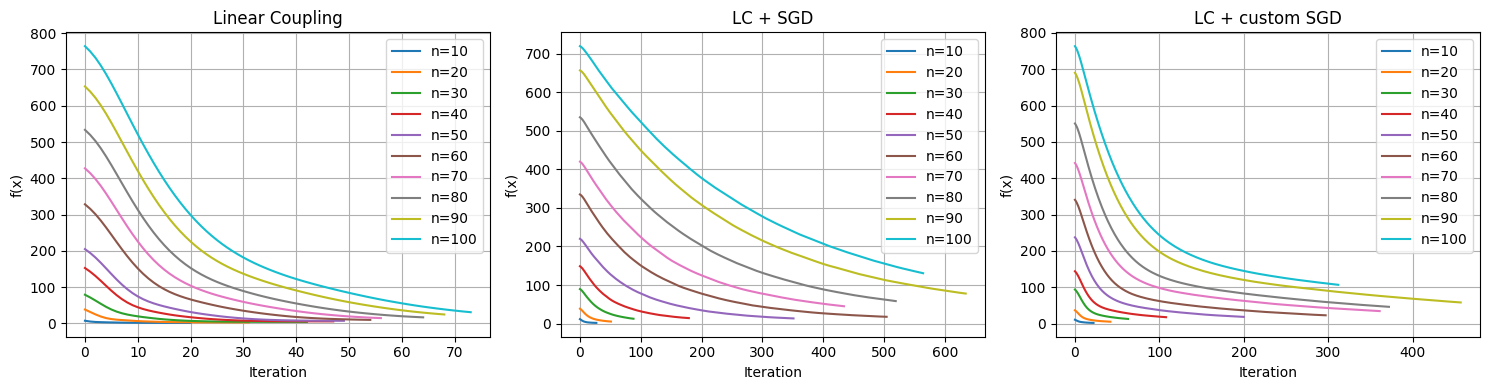

In [42]:
plot_results(
    [lc_mom_results, lc_mom_sgd_results, lc_mom_custom_sgd_results],
    ["Linear Coupling", "LC + SGD", "LC + custom SGD"],
    plot_type="convergence",
)

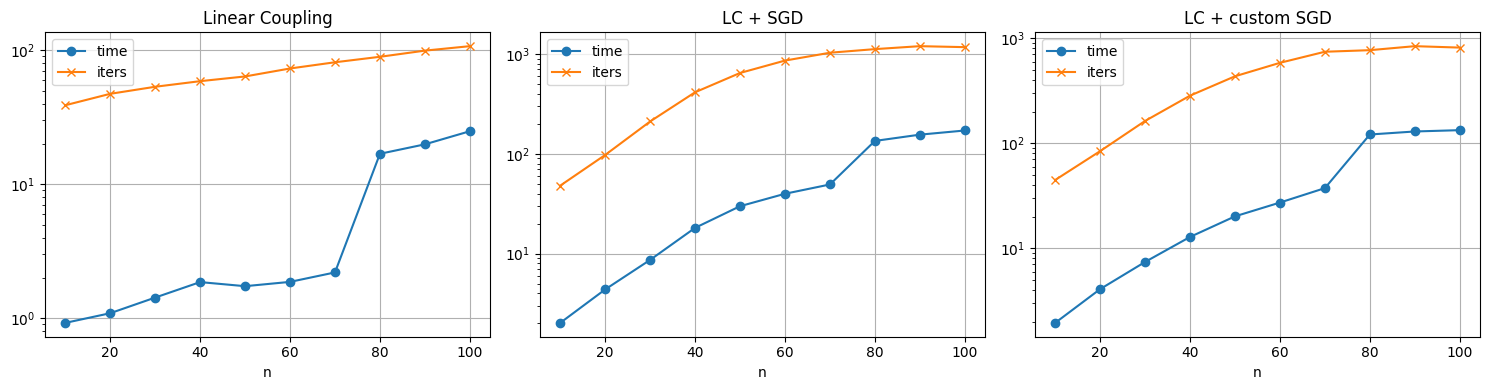

In [57]:
plot_results(
    [lc_mom_results, lc_mom_sgd_results, lc_mom_custom_sgd_results],
    ["Linear Coupling", "LC + SGD", "LC + custom SGD"],
    plot_type="scaling",
)

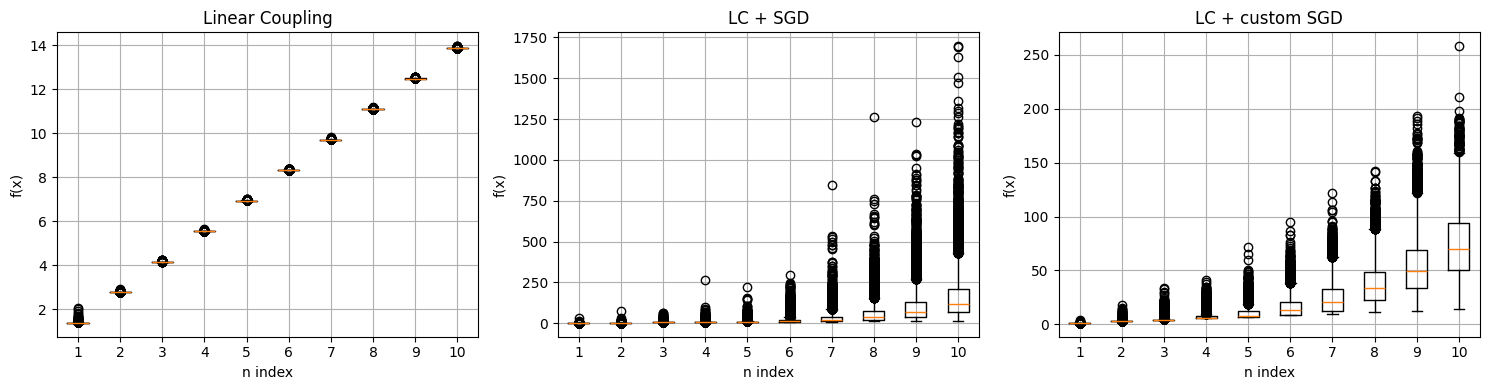

In [45]:
plot_results(
    [lc_mom_results, lc_mom_sgd_results, lc_mom_custom_sgd_results],
    ["Linear Coupling", "LC + SGD", "LC + custom SGD"],
    plot_type="boxplot",
)

### Linear coupling with momentum, SGD + mini-batching

batch_size = 1

In [82]:
lc_mom_sgd_batch1_results = run_experiment_multiprocess(
    LinearCoupling,
    grad="stochastic_mini_batch",
    method_kwargs={"beta": 0.7, "tau": 0.3, "batch_size": 1},
)

LinearCoupling: 100%|██████████| 10/10 [09:10<00:00, 55.04s/it]


batch_size = n / 10

In [83]:
lc_mom_sgd_batch_n10_results = run_experiment_multiprocess(
    LinearCoupling,
    grad="stochastic_mini_batch",
    method_kwargs={"beta": 0.7, "tau": 0.3, "batch_size": "n/10"},
)

LinearCoupling: 100%|██████████| 10/10 [09:36<00:00, 57.61s/it] 


batch_size = n / 5

In [ ]:
lc_mom_sgd_batch_n5_results = run_experiment_multiprocess(
    LinearCoupling,
    grad="stochastic_mini_batch",
    method_kwargs={"beta": 0.7, "tau": 0.3, "batch_size": "n/5"},
)

batch_size = n / 2

In [ ]:
lc_mom_sgd_batch_n2_results = run_experiment_multiprocess(
    LinearCoupling,
    grad="stochastic_mini_batch",
    method_kwargs={"beta": 0.7, "tau": 0.3, "batch_size": "n/2"},
)

batch_size = n

In [ ]:
lc_mom_sgd_batch_n_results = run_experiment_multiprocess(
    LinearCoupling,
    grad="stochastic_mini_batch",
    method_kwargs={"beta": 0.7, "tau": 0.3, "batch_size": "n"},
)

In [ ]:
plot_results(
    [lc_mom_sgd_batch1_results, lc_mom_sgd_batch_n10_results, lc_mom_sgd_batch_n5_results, lc_mom_sgd_batch_n2_results, lc_mom_sgd_batch_n_results],
    ["batch=1", "batch=n/10", "batch=n/5", "batch=n/2", "batch=n"],
    plot_type="convergence",
)

### Linear coupling with custom SGD + mini-batching

batch_size = 1

In [ ]:
lc_mom_custom_sgd_batch_1_results = run_experiment_multiprocess(
    LinearCoupling,
    grad="stochastic_custom_mini_batch",
    method_kwargs={"beta": 0.7, "tau": 0.3, "batch_size": 1},
)

Running LinearCoupling: 100%|██████████| 10/10 [00:14<00:00,  1.50s/it]


batch_size = n / 10

In [ ]:
lc_mom_custom_sgd_batch_n10_results = run_experiment_multiprocess(
    LinearCoupling,
    grad="stochastic_custom_mini_batch",
    method_kwargs={"beta": 0.7, "tau": 0.3, "batch_size": "n/10"},
)

batch_size = n / 5

In [ ]:
lc_mom_custom_sgd_batch_n5_results = run_experiment_multiprocess(
    LinearCoupling,
    grad="stochastic_custom_mini_batch",
    method_kwargs={"beta": 0.7, "tau": 0.3, "batch_size": "n/5"},
)

batch_size = n / 2

In [ ]:
lc_mom_custom_sgd_batch_n2_results = run_experiment_multiprocess(
    LinearCoupling,
    grad="stochastic_custom_mini_batch",
    method_kwargs={"beta": 0.7, "tau": 0.3, "batch_size": "n/2"},
)

batch_size = n

In [ ]:
lc_mom_custom_sgd_batch_n_results = run_experiment_multiprocess(
    LinearCoupling,
    grad="stochastic_custom_mini_batch",
    method_kwargs={"beta": 0.7, "tau": 0.3, "batch_size": "n"},
)

In [ ]:
plot_results(
    [lc_mom_custom_sgd_batch_1_results, lc_mom_custom_sgd_batch_n10_results, lc_mom_custom_sgd_batch_n5_results, lc_mom_custom_sgd_batch_n2_results, lc_mom_custom_sgd_batch_n_results],
    ["batch=1", "batch=n/10", "batch=n/5", "batch=n/2", "batch=n"],
    plot_type="convergence",
)

---

## Nesterov method

In [ ]:
nesterov_results = run_experiment_multiprocess(
    Nesterov,
    grad="complete",
    method_kwargs={"tau": 0.7}
)

Running Nesterov: 100%|██████████| 10/10 [00:02<00:00,  4.88it/s]


При $\tau < 1$ добавляется искусственное затухание, поэтому есть сходимость \
Но если сразу поставить $\tau = 1$, то затухания нет.

### Nesterov SGD

In [ ]:
nesterov_sgd_results = run_experiment_multiprocess(
    Nesterov,
    grad="stochastic",
    method_kwargs={"tau": 0.5}
)

Running Nesterov: 100%|██████████| 10/10 [00:06<00:00,  1.43it/s]


С большим $\tau$ (> 0.9) не сходится, даже с меньшим значением есть долгие колебния около минимума \

Nesterov чувствителен к шуму градиента. \
При добавлении SGD, шум добавляется в направление движения, и momentum начинает этот шум накапливать, из-за чего появляются колебания. При больших $\tau$ это усиливается.

### Nesterov with custom SGD

In [ ]:
nesterov_custom_sgd_results = run_experiment_multiprocess(
    Nesterov,
    grad="stochastic_custom",
    method_kwargs={"tau": 0.5},
)

Running Nesterov: 100%|██████████| 10/10 [00:11<00:00,  1.13s/it]


In [ ]:
plot_results(
    [nesterov_results, nesterov_sgd_results, nesterov_custom_sgd_results],
    ["Nesterov", "Nesterov + SGD", "Nesterov + custom SGD"],
    plot_type="convergence",
)

### Nesterov, SGD + mini-batching

batch_size = 1

In [ ]:
nesterov_sgd_batch_1_results = run_experiment_multiprocess(
    Nesterov,
    grad="stochastic_mini_batch",
    method_kwargs={"tau": 0.5, "batch_size": 1},
)

Running Nesterov: 100%|██████████| 10/10 [00:13<00:00,  1.34s/it]


batch_size = n / 10

In [ ]:
nesterov_sgd_batch_n10_results = run_experiment_multiprocess(
    Nesterov,
    grad="stochastic_mini_batch",
    method_kwargs={"tau": 0.5, "batch_size": "n/10"},
)

batch_size = n / 5

In [ ]:
nesterov_sgd_batch_n5_results = run_experiment_multiprocess(
    Nesterov,
    grad="stochastic_mini_batch",
    method_kwargs={"tau": 0.5, "batch_size": "n/5"},
)

batch_size = n / 2

In [ ]:
nesterov_sgd_batch_n2_results = run_experiment_multiprocess(
    Nesterov,
    grad="stochastic_mini_batch",
    method_kwargs={"tau": 0.5, "batch_size": "n/2"},
)

batch_size = n

In [ ]:
nesterov_sgd_batch_n_results = run_experiment_multiprocess(
    Nesterov,
    grad="stochastic_mini_batch",
    method_kwargs={"tau": 0.5, "batch_size": "n"},
)

In [ ]:
plot_results(
    [nesterov_sgd_batch_1_results, nesterov_sgd_batch_n10_results, nesterov_sgd_batch_n5_results, nesterov_sgd_batch_n2_results, nesterov_sgd_batch_n_results],
    ["batch=1", "batch=n/10", "batch=n/5", "batch=n/2", "batch=n"],
    plot_type="convergence",
)

### Nesterov, cusom SGD + mini-batching

batch_size = 1

In [ ]:
nesterov_sgd_batch_1_results = run_experiment_multiprocess(
    Nesterov,
    grad="stochastic_custom_mini_batch",
    method_kwargs={"tau": 0.5, "batch_size": 1},
)

batch_size = n / 10

In [ ]:
nesterov_sgd_batch_n10_results = run_experiment_multiprocess(
    Nesterov,
    grad="stochastic_custom_mini_batch",
    method_kwargs={"tau": 0.5, "batch_size": "n/10"},
)

batch_size = n / 5

In [ ]:
nesterov_sgd_batch_n5_results = run_experiment_multiprocess(
    Nesterov,
    grad="stochastic_custom_mini_batch",
    method_kwargs={"tau": 0.5, "batch_size": "n/5"},
)

batch_size = n / 2

In [ ]:
nesterov_sgd_batch_n2_results = run_experiment_multiprocess(
    Nesterov,
    grad="stochastic_custom_mini_batch",
    method_kwargs={"tau": 0.5, "batch_size": "n/2"},
)

batch_size = n

In [ ]:
nesterov_sgd_batch_n_results = run_experiment_multiprocess(
    Nesterov,
    grad="stochastic_custom_mini_batch",
    method_kwargs={"tau": 0.5, "batch_size": "n"},
)

In [ ]:
plot_results(
    [nesterov_sgd_batch_1_results, nesterov_sgd_batch_n10_results, nesterov_sgd_batch_n5_results, nesterov_sgd_batch_n2_results, nesterov_sgd_batch_n_results],
    ["batch=1", "batch=n/10", "batch=n/5", "batch=n/2", "batch=n"],
    plot_type="convergence",
)